In [3]:
# import sys
# print("Python version:", sys.version)

import pandas as pd
print("pandas version:", pd.__version__)

import matplotlib
print("matplotlib version:", matplotlib.__version__)

import numpy as np
print("NumPy version:", np.__version__)

# import scipy as sp
# print("SciPy version:", sp.__version__)

# import IPython
# print("IPython version:", IPython.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)

pandas version: 2.2.2
matplotlib version: 3.10.0
NumPy version: 2.0.2
scikit-learn version: 1.6.1


In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    cohen_kappa_score
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# считать датасет
from sklearn.datasets import load_iris
iris_dataset = load_iris()

print(iris_dataset.keys())
print(iris_dataset.target_names)
print(iris_dataset.feature_names)
print(iris_dataset.data[:3])
print(iris_dataset.target[:3])
iris_dataset.data.shape

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
[0 0 0]


(150, 4)

In [11]:
# объеденить в одну таблицу для чистоты понимания
df = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
df['target'] = iris_dataset.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
# общая информация, виден полный список колонок и пропуски в них
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [13]:
# распределение целевых классов
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


In [14]:
# разбивка на обучающую тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'],
                                                    iris_dataset['target'],
                                                    test_size=0.3,
                                                    stratify=df['target'],
                                                    random_state=0)

In [15]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (105, 4)
y_train shape: (105,)


In [16]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (45, 4)
y_test shape: (45,)


## k-Nearest Neighbors

In [17]:
# from sklearn.neighbors import KNeighborsClassifier
# knn = KNeighborsClassifier(n_neighbors=1)

In [18]:
# knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [19]:
# X_new = np.array([[5, 2.9, 1, 0.2]])
# knn.predict(X_new)


array([0])

In [20]:
# y_pred = knn.predict(X_test)
# knn.score(X_test, y_test)

0.9777777777777777

#RandomForestClassifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
# 3. Обучение модели (Random Forest как пример)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Предсказания
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  0 15]]



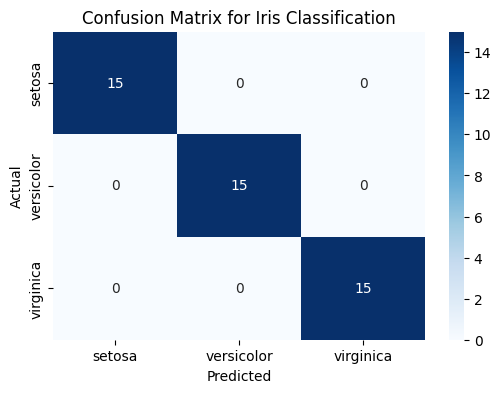

In [28]:
# 4.1 Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
print("=" * 60)
print("Confusion Matrix:")
print(cm)
print()

# Визуализация матрицы ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=iris_dataset.target_names,
            yticklabels=iris_dataset.target_names
)
plt.title('Confusion Matrix for Iris Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
# 4.2 Основные метрики
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

kappa = cohen_kappa_score(y_test, y_pred)

print("=" * 60)
print("ОСНОВНЫЕ МЕТРИКИ КЛАССИФИКАЦИИ:")
print(f"Accuracy: {accuracy:.2}")
print()
print(f"Precision (macro): {precision_macro:.2}")
print(f"Precision (micro): {precision_micro:.2}")
print(f"Precision (weighted): {precision_weighted:.2}")
print()
print(f"Recall (macro): {recall_macro:.2}")
print(f"Recall (micro): {recall_micro:.2}")
print(f"Recall (weighted): {recall_weighted:.2}")
print()
print(f"F1-Score (macro): {f1_macro:.2}")
print(f"F1-Score (micro): {f1_micro:.2}")
print(f"F1-Score (weighted): {f1_weighted:.2}")
print()
print(f"Cohen's Kappa: {kappa:.4f}")

ОСНОВНЫЕ МЕТРИКИ КЛАССИФИКАЦИИ:
Accuracy: 1.0

Precision (macro): 1.0
Precision (micro): 1.0
Precision (weighted): 1.0

Recall (macro): 1.0
Recall (micro): 1.0
Recall (weighted): 1.0

F1-Score (macro): 1.0
F1-Score (micro): 1.0
F1-Score (weighted): 1.0

Cohen's Kappa: 1.0000


In [33]:
# 4.4 Полный отчет по каждому классу
print("\n" + "=" * 60)
print("ПОДРОБНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print(classification_report(y_test, y_pred, target_names=iris_dataset.target_names))


ПОДРОБНЫЙ ОТЧЕТ ПО КЛАССАМ:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45




Feature Importance (from Random Forest):
             feature  importance
3   petal width (cm)    0.445112
2  petal length (cm)    0.412716
0  sepal length (cm)    0.113168
1   sepal width (cm)    0.029004


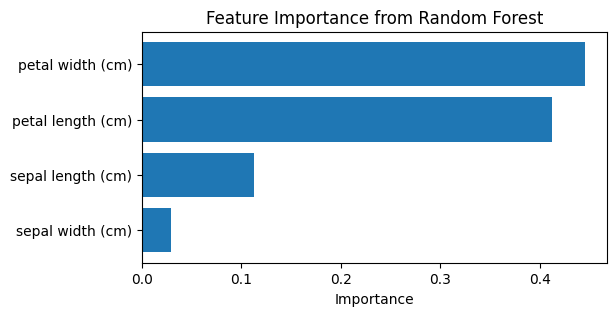

In [38]:
# 5.1 Важность признаков из модели (для Random Forest)
feature_importance = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (from Random Forest):")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(6, 3))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [40]:
#
# мудреный статистический тест, потом разобраться
#
# 5.2 ANOVA F-тест (линейная зависимость)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_train, y_train)
f_scores = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'f_score': selector_f.scores_,
    'p_value': selector_f.pvalues_
}).sort_values('f_score', ascending=False)

print("\nANOVA F-test scores:")
print(f_scores)


ANOVA F-test scores:
             feature     f_score       p_value
2  petal length (cm)  711.374311  1.245943e-60
3   petal width (cm)  701.116655  2.486185e-60
0  sepal length (cm)   82.835066  4.275758e-22
1   sepal width (cm)   33.772813  5.558947e-12


In [41]:
#
# мудреный статистический тест, потом разобраться
#
# 5.3 Mutual Information (нелинейная зависимость)
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print("\nMutual Information scores:")
print(mi_df)


Mutual Information scores:
             feature  mutual_info
3   petal width (cm)     0.990572
2  petal length (cm)     0.963346
0  sepal length (cm)     0.526634
1   sepal width (cm)     0.268780


In [42]:
#
# мудреный статистический тест, потом разобраться
#
# 5.4 Permutation Importance (самый надежный метод)
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("\nPermutation Importance (mean ± std):")
print(perm_df)


Permutation Importance (mean ± std):
             feature  importance       std
2  petal length (cm)    0.288889  0.045542
3   petal width (cm)    0.140000  0.038554
0  sepal length (cm)    0.013333  0.014741
1   sepal width (cm)    0.000000  0.000000


In [44]:
# 5.5 Дополнительно: корреляция признаков с целевой переменной
correlations = pd.DataFrame({
    'feature': iris_dataset.feature_names,
    'correlation': [np.corrcoef(X_train[:, i], y_train)[0, 1] for i in range(X_train.shape[1])]
}).sort_values('correlation', ascending=False)

print("\nCorrelation with target:")
print(correlations)


Correlation with target:
             feature  correlation
3   petal width (cm)     0.959756
2  petal length (cm)     0.948006
0  sepal length (cm)     0.786458
1   sepal width (cm)    -0.409515


/tmp/ipykernel_722/2343109301.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Metric', y='Score', palette='viridis')


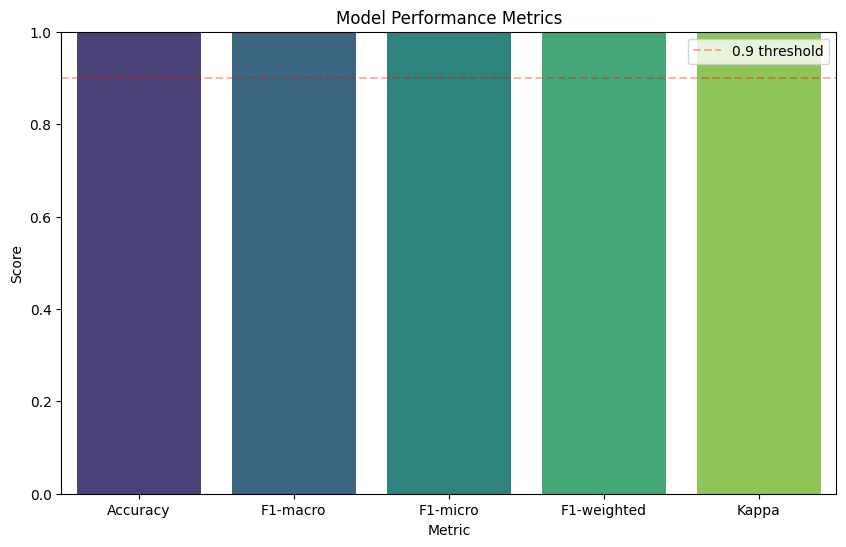

In [53]:
# Сравнение метрик в одном графике
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-macro', 'F1-micro', 'F1-weighted', 'Kappa'],
    'Score': [accuracy, f1_macro, f1_micro, f1_weighted, kappa]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Score', palette='viridis')
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.3, label='0.9 threshold')
plt.legend()
plt.show()

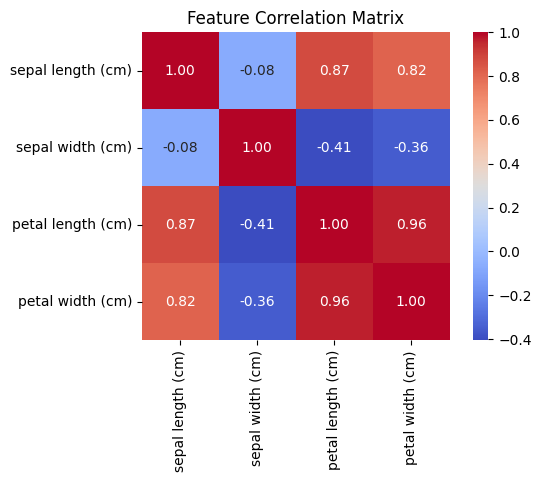

In [50]:
# Корреляционная матрица признаков
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(X_train,
                         columns=iris_dataset.feature_names).corr(),
                         annot=True,
                         fmt='.2f',
                         cmap='coolwarm',
                         square=True
)
plt.title('Feature Correlation Matrix')
plt.show()